In [20]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Arial"


No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.70
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.75
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.80
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.85
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.90
No directory found for DFS_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.70
No directory found for DFS_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.75
No directory found for DFS_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.80
No directory found for DFS_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.85
No directory found for DFS_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.90
No directory found for Proposed_bou

/home/pacs/.local/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/pacs/.local/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


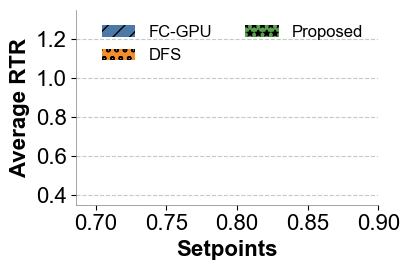

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- CONFIG ----------------
fc_root = Path("FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted")
dfs_root = Path("DFS_bounds/histogram_converted_mm_converted_bfs_converted")
prop_root = Path("Proposed_bounds/histogram_converted_mm_converted_bfs_converted")

setpoints = [0.70, 0.75, 0.80, 0.85, 0.90]
save_path = Path("figures")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

#colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
#hatches = ['//', 'oo', 'xx']
colors=['#525252', '#56B4E9', '#009E73',  '#F0E442', '#FF7F00']
colors=['#56B4E9', '#009E73',  '#F0E442']
colors=['#525252', '#009E73',  '#F0E442']
colors  = ['#4E79A7', '#F28E2B', '#59A14F']
hatches = ["//", "oo", "**", "xx"]
labels = ["FC-GPU", "DFS", "Proposed"]


# ---------------- HELPERS ----------------
def read_data(filepath: Path):
    if not filepath.exists():
        print(f"Missing: {filepath}")
        return np.array([])
    try:
        return np.loadtxt(filepath)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return np.array([])

def safe_slice(arr):
    if arr.size == 0:
        return arr
    return arr[100:-1] if arr.size > 101 else arr

def mean_std(arr):
    arr = safe_slice(arr)
    if arr.size == 0:
        return np.nan, np.nan
    return float(np.mean(arr)), float(np.std(arr))

def find_setpoint_dir(root: Path, sp: float):
    candidates = [
        root / f"setpoint_{sp:.2f}",
        root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}",
    ]
    for c in candidates:
        if c.exists():
            return c
    print(f"No directory found for {root} setpoint {sp:.2f}")
    return None

def fc_or_prop_avg_rtr(root: Path, prefix: str):
    means = []
    stds = []

    for sp in setpoints:
        run_dir = find_setpoint_dir(root, sp)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        t1 = read_data(run_dir / f"{prefix}_t1_rtr.txt")
        t2 = read_data(run_dir / f"{prefix}_t2_rtr.txt")
        t3 = read_data(run_dir / f"{prefix}_t3_rtr.txt")

        t1 = safe_slice(t1)
        t2 = safe_slice(t2)
        t3 = safe_slice(t3)

        n = min(len(t1), len(t2), len(t3))
        if n == 0:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        avg_trace = (t1[:n] + t2[:n] + t3[:n]) / 3.0
        means.append(np.mean(avg_trace))
        stds.append(np.std(avg_trace))

    return np.array(means), np.array(stds)

def dfs_avg_rtr(root: Path):
    means = []
    stds = []

    for sp in setpoints:
        run_dir = find_setpoint_dir(root, sp)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        candidates = [
            run_dir / "DFSaveragertr.txt",
            run_dir / "DFS_average_rtr.txt",
            run_dir / "averagertr.txt",
        ]

        arr = np.array([])
        for c in candidates:
            if c.exists():
                arr = read_data(c)
                break

        m, s = mean_std(arr)
        means.append(m)
        stds.append(s)

    return np.array(means), np.array(stds)

# ---------------- COLLECT ----------------
fc_means, fc_stds = fc_or_prop_avg_rtr(fc_root, "FC_GPU")
dfs_means, dfs_stds = dfs_avg_rtr(dfs_root)
prop_means, prop_stds = fc_or_prop_avg_rtr(prop_root, "Proposed")

print("FC-GPU:", fc_means)
print("DFS:", dfs_means)
print("Proposed:", prop_means)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(4.2, 2.8))

all_means = [fc_means, dfs_means, prop_means]
all_stds = [fc_stds, dfs_stds, prop_stds]

x = np.arange(len(setpoints))
bar_width = 0.22

for i in range(3):
    ax.bar(
        x + i * bar_width,
        all_means[i],
        bar_width,
        yerr=all_stds[i],
        color=colors[i],
        hatch=hatches[i],
        capsize=3,
        linewidth=0.8,
        label=labels[i],
    )

#     ax.set_ylabel("Average Power (W)"
# ax.set_xlabel("Scheduling Solutions", fontsize=16,fontweight="bold")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)


ax.set_xlabel("Setpoints", fontsize=16,fontweight="bold")
ax.set_ylabel("Average RTR", fontsize=16,fontweight="bold")
ax.set_xticks(x + bar_width)
ax.set_xticklabels([f"{sp:.2f}" for sp in setpoints])
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)
ax.legend(frameon=False,ncols=2)
ax.set_ylim([0.35,1.35])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
save_path.mkdir(exist_ok=True)
plt.savefig(save_path / "average_rtr_barplot.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()

No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.70
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.75
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.80
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.85
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.90
No directory found for Proposed_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.70
No directory found for Proposed_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.75
No directory found for Proposed_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.80
Missing: Proposed_bounds/histogram_converted_mm_converted_bfs_converted/setpoint_0.85/Proposed_t1_deadline.txt
Missing: Proposed_bounds/histogram_converted_mm_converted_bfs_converted/setpoint_0.85/Proposed_t2_d

/home/pacs/.local/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/pacs/.local/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


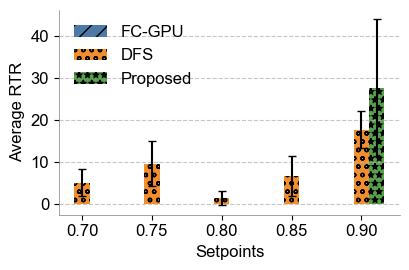

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- CONFIG ----------------
fc_root = Path("FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted")
dfs_root = Path("DFS_bounds/histogram_converted_mm_converted_bfs_converted")
prop_root = Path("Proposed_bounds/histogram_converted_mm_converted_bfs_converted")

setpoints = [0.70, 0.75, 0.80, 0.85, 0.90]
save_path = Path("figures")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors  = ['#4E79A7', '#F28E2B', '#59A14F']
hatches = ["//", "oo", "**", "xx"]
labels = ["FC-GPU", "DFS", "Proposed"]

# ---------------- HELPERS ----------------
def read_data(filepath: Path):
    if not filepath.exists():
        print(f"Missing: {filepath}")
        return np.array([])
    try:
        return np.loadtxt(filepath)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return np.array([])

def safe_slice(arr):
    if arr.size == 0:
        return arr
    return arr[100:-1] if arr.size > 101 else arr

def mean_std(arr):
    arr = safe_slice(arr)
    if arr.size == 0:
        return np.nan, np.nan
    return float(np.mean(arr)), float(np.std(arr))

def find_setpoint_dir(root: Path, sp: float):
    candidates = [
        root / f"setpoint_{sp:.2f}",
        root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}",
    ]
    for c in candidates:
        if c.exists():
            return c
    print(f"No directory found for {root} setpoint {sp:.2f}")
    return None

def fc_or_prop_avg_rtr(root: Path, prefix: str):
    means = []
    stds = []

    for sp in setpoints:
        run_dir = find_setpoint_dir(root, sp)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        t1 = read_data(run_dir / f"{prefix}_t1_deadline.txt")
        t2 = read_data(run_dir / f"{prefix}_t2_deadline.txt")
        t3 = read_data(run_dir / f"{prefix}_t3_deadline.txt")

        t1 = safe_slice(t1)
        t2 = safe_slice(t2)
        t3 = safe_slice(t3)

        n = min(len(t1), len(t2), len(t3))
        if n == 0:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        avg_trace = (t1[:n] + t2[:n] + t3[:n]) / 3.0
        means.append(np.mean(avg_trace))
        stds.append(np.std(avg_trace))

    return np.array(means), np.array(stds)

# ---------------- COLLECT ----------------
fc_means, fc_stds = fc_or_prop_avg_rtr(fc_root, "FC_GPU")
dfs_means, dfs_stds = fc_or_prop_avg_rtr(dfs_root,"DFS")
prop_means, prop_stds = fc_or_prop_avg_rtr(prop_root, "Proposed")

print("FC-GPU:", fc_means)
print("DFS:", dfs_means)
print("Proposed:", prop_means)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(4.2, 2.8))

all_means = [fc_means, dfs_means, prop_means]
all_stds = [fc_stds, dfs_stds, prop_stds]

x = np.arange(len(setpoints))
bar_width = 0.22

for i in range(3):
    ax.bar(
        x + i * bar_width,
        all_means[i],
        bar_width,
        yerr=all_stds[i],
        color=colors[i],
        hatch=hatches[i],
        capsize=3,
        linewidth=0.8,
        label=labels[i],
    )

ax.set_xlabel("Setpoints")
ax.set_ylabel("Average RTR")
ax.set_xticks(x + bar_width)
ax.set_xticklabels([f"{sp:.2f}" for sp in setpoints])
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)
ax.legend(frameon=False)
plt.tight_layout()
save_path.mkdir(exist_ok=True)
plt.savefig(save_path / "average_rtr_barplot.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()

No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.70
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.75
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.80
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.85
No directory found for FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.90
No directory found for Proposed_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.70
No directory found for Proposed_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.75
No directory found for Proposed_bounds/histogram_converted_mm_converted_bfs_converted setpoint 0.80
Missing: Proposed_bounds/histogram_converted_mm_converted_bfs_converted/setpoint_0.85/Proposed_finalpowervalues.txt
FC-GPU: [nan nan nan nan nan]
DFS: [117.86536346 119.2038625  105.06623173  91.35893942  88.27

/home/pacs/.local/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/pacs/.local/lib/python3.8/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


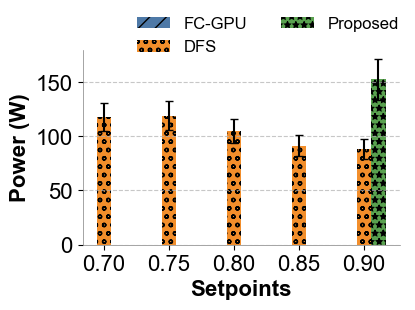

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- CONFIG ----------------
fc_root = Path("FC-GPU_bounds/histogram_converted_mm_converted_bfs_converted")
dfs_root = Path("DFS_bounds/histogram_converted_mm_converted_bfs_converted")
prop_root = Path("Proposed_bounds/histogram_converted_mm_converted_bfs_converted")

setpoints = [0.70, 0.75, 0.80, 0.85, 0.90]
save_path = Path("figures")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

colors  = ['#4E79A7', '#F28E2B', '#59A14F']
hatches = ["//", "oo", "**", "xx"]
labels = ["FC-GPU", "DFS", "Proposed"]
# ---------------- HELPERS ----------------
def read_data(filepath: Path):
    if not filepath.exists():
        print(f"Missing: {filepath}")
        return np.array([])
    try:
        data = np.loadtxt(filepath)
        return np.atleast_1d(data)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return np.array([])

def safe_slice(arr):
    if arr.size == 0:
        return arr
    return arr[100:-1] if arr.size > 101 else arr

def mean_std(arr):
    arr = safe_slice(arr)
    if arr.size == 0:
        return np.nan, np.nan
    return float(np.mean(arr)), float(np.std(arr))

def find_setpoint_dir(root: Path, sp: float):
    candidates = [
        root / f"setpoint_{sp:.2f}",
        root / f"setpoint_{sp:.2f}_{sp:.2f}_{sp:.2f}",
    ]
    for c in candidates:
        if c.exists():
            return c
    print(f"No directory found for {root} setpoint {sp:.2f}")
    return None

def fc_or_prop_avg_power(root: Path, prefix: str):
    means = []
    stds = []

    for sp in setpoints:
        run_dir = find_setpoint_dir(root, sp)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        arr = read_data(run_dir / f"{prefix}_finalpowervalues.txt")
        m, s = mean_std(arr)
        means.append(m)
        stds.append(s)

    return np.array(means), np.array(stds)

def dfs_avg_power(root: Path):
    means = []
    stds = []

    for sp in setpoints:
        run_dir = find_setpoint_dir(root, sp)
        if run_dir is None:
            means.append(np.nan)
            stds.append(np.nan)
            continue

        arr = read_data(run_dir / "DFS_finalpowervalues.txt")
        m, s = mean_std(arr)
        means.append(m)
        stds.append(s)

    return np.array(means), np.array(stds)

# ---------------- COLLECT ----------------
fc_means, fc_stds = fc_or_prop_avg_power(fc_root, "FC_GPU")
dfs_means, dfs_stds = dfs_avg_power(dfs_root)
prop_means, prop_stds = fc_or_prop_avg_power(prop_root, "Proposed")

print("FC-GPU:", fc_means)
print("DFS:", dfs_means)
print("Proposed:", prop_means)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(4.2, 2.8))

all_means = [fc_means, dfs_means, prop_means]
all_stds = [fc_stds, dfs_stds, prop_stds]

x = np.arange(len(setpoints))
bar_width = 0.22

for i in range(3):
    ax.bar(
        x + i * bar_width,
        all_means[i],
        bar_width,
        yerr=all_stds[i],
        color=colors[i],
        hatch=hatches[i],
        capsize=3,
        linewidth=0.8,
        label=labels[i],
    )

ax.set_xlabel("Setpoints", fontsize=16,fontweight="bold")
ax.set_ylabel("Power (W)", fontsize=16,fontweight="bold")
ax.set_xticks(x + bar_width)
ax.set_xticklabels([f"{sp:.2f}" for sp in setpoints])
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
handles, labels_ = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels_,
    loc="upper center",
    bbox_to_anchor=(0.65, 1.12),
    ncol=2,
    frameon=False,
)
plt.tight_layout()

save_path.mkdir(exist_ok=True)
plt.savefig(save_path / "average_power_barplot.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()